##**1.Environment Setup**


####Using Google Collab for Training

####Installing Libraries

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn tensorflow keras transformers

##**2.Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


##**3.Loading Dataset Files**

####Loading Kaggle emotion dataset (train, test, validation)

In [ ]:
train_df = pd.read_csv("train.txt", sep=";", names=["text", "emotion"])
test_df = pd.read_csv("test.txt", sep=";", names=["text", "emotion"])
val_df = pd.read_csv("val.txt", sep=";", names=["text", "emotion"])

print(train_df.head())


                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


##**4.Preprocessing**

####Combine train + validation then convert to numerical features

In [ ]:
full_train = pd.concat([train_df, val_df])

X_train = full_train['text']
y_train = full_train['emotion']

X_test = test_df['text']
y_test = test_df['emotion']

####TF-IDF vectorization

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

####Encode labels

In [ ]:
y_train_encoded = pd.get_dummies(y_train).values
y_test_encoded = pd.get_dummies(y_test).values

##**5.Model**

####Building a simple Neural Network with multiple hidden layers

In [ ]:
model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train_vec.shape[1],)),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(y_train_encoded.shape[1], activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##**6.Training**

####Training the model for 20 epochs, batch size 32

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_vec, y_train_encoded,
                    epochs=20, batch_size=32,
                    validation_data=(X_test_vec, y_test_encoded))

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 149s 261ms/step - accuracy: 0.9966 - loss: 0.0143 - val_accuracy: 0.8590 - val_loss: 1.2432
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 134s 238ms/step - accuracy: 0.9956 - loss: 0.0156 - val_accuracy: 0.8465 - val_loss: 1.3628
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 131s 233ms/step - accuracy: 0.9951 - loss: 0.0173 - val_accuracy: 0.8505 - val_loss: 1.4101
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 246ms/step - accuracy: 0.9947 - loss: 0.0181 - val_accuracy: 0.8490 - val_loss: 1.2074
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 151s 263ms/step - accuracy: 0.9947 - loss: 0.0175 - val_accuracy: 0.8605 - val_loss: 1.1530
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9953 - loss: 0.0133 - val_accuracy: 0.8485 - val_loss: 1.2660
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 147s 256ms/step - accuracy: 0.9963 - loss: 0.0102 - val_accuracy: 0.8590 - val_loss: 1.3178
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 203s 258ms/step - accuracy: 0.9964 -

##**7.Evaluation**

####Evaluating model performance: precision, recall, F1‑score, and confusion matrix.

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       275
           1       0.88      0.79      0.83       224
           2       0.88      0.93      0.91       695
           3       0.77      0.72      0.74       159
           4       0.93      0.88      0.91       581
           5       0.60      0.73      0.66        66

    accuracy                           0.87      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.87      0.87      0.87      2000



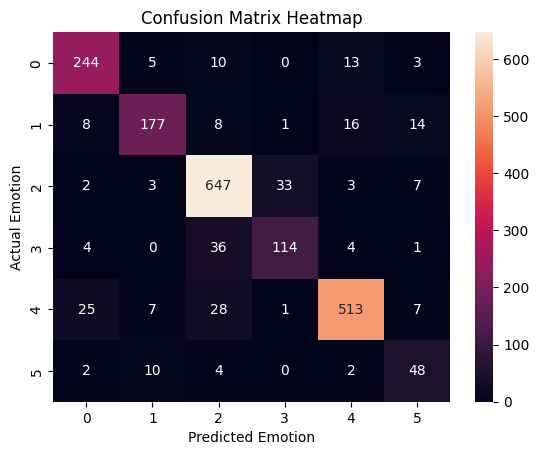

In [ ]:
y_pred = model.predict(X_test_vec)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print(classification_report(y_true, y_pred_classes))

sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()


####Dataset distribution

######Distribution of emotions in training data.

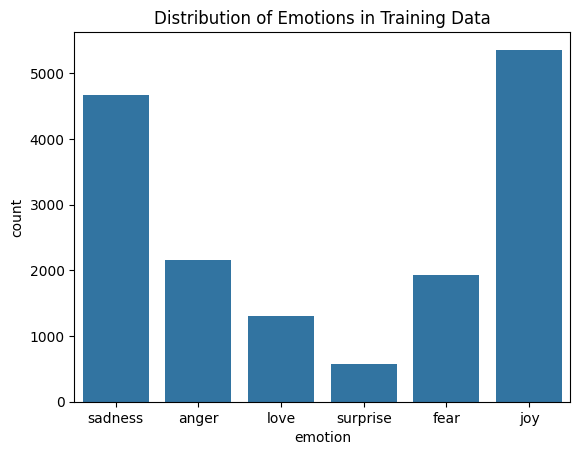

In [ ]:
sns.countplot(x='emotion', data=train_df)
plt.title("Distribution of Emotions in Training Data")
plt.show()


####Training Accuracy & Loss

######Training progress: accuracy and loss curves.

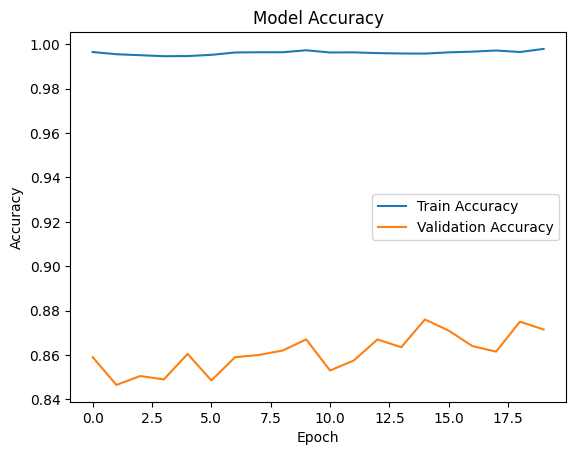

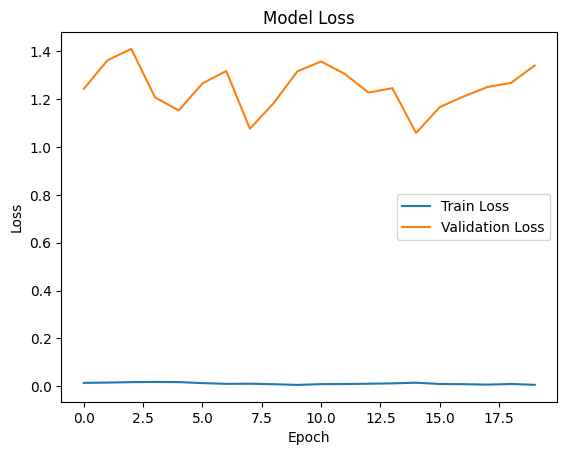

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


####Prediction Histogram

######Predicted emotion counts by the model.

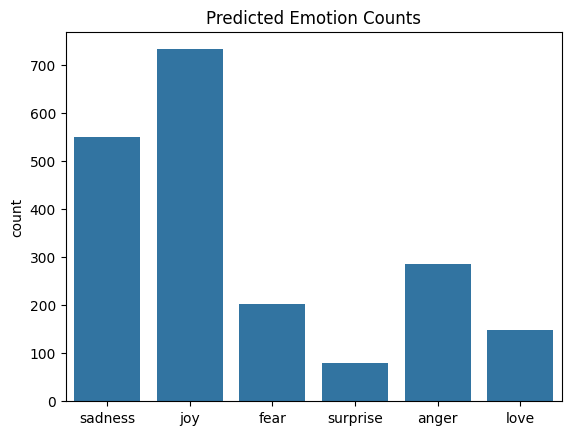

In [ ]:
pred_labels = [list(pd.get_dummies(y_train).columns)[i] for i in y_pred_classes]
sns.countplot(x=pred_labels)
plt.title("Predicted Emotion Counts")
plt.show()

##**Bonus Demo**

###Run Hugging Face pipeline live.

######Quick demo with pre‑trained model for instant text emotion detection

In [44]:
from transformers import pipeline

# Load pre-trained emotion model
emotion_model = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

# Ask user for input
user_text = input("Enter a sentence to analyze emotion: ")
print(emotion_model(user_text))

while True:
    user_text = input("Enter a sentence (or type 'exit' to quit): ")
    if user_text.lower() == 'exit':
        break
    print(emotion_model(user_text))



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Enter a sentence to analyze emotion: I am very happy.
[{'label': 'joy', 'score': 0.9794984459877014}]
Enter a sentence (or type 'exit' to quit): I am very happy but a bit sad too.
[{'label': 'sadness', 'score': 0.9823082685470581}]
Enter a sentence (or type 'exit' to quit): i am anxious.
[{'label': 'fear', 'score': 0.9940259456634521}]
Enter a sentence (or type 'exit' to quit): exit
